In [1]:
from non_local_detector.simulate.sorted_spikes_simulation import make_simulated_data

(
    speed,
    position,
    spike_times,
    time,
    event_times,
    sampling_frequency,
    is_event,
    place_fields,
) = make_simulated_data(n_neurons=30)

/Users/edeno/Documents/GitHub/non_local_detector/src/non_local_detector/likelihoods/clusterless_gmm.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # type: ignore[import-untyped]


In [2]:
from non_local_detector import NonLocalSortedSpikesDetector

detector = NonLocalSortedSpikesDetector(
    sorted_spikes_algorithm="sorted_spikes_kde",
    non_local_position_penalty=1.0,
    non_local_penalty_sigma=5.0,
)

is_training = ~is_event

results = detector.estimate_parameters(
    position_time=time,
    position=position,
    spike_times=spike_times,
    is_training=is_training,
    time=time,
    store_log_likelihood=True,
)
results

Encoding models:   0%|          | 0/30 [00:00<?, ?cell/s]

Local Likelihood:   0%|          | 0/30 [00:00<?, ?cell/s]

No Spike Likelihood:   0%|          | 0/30 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/30 [00:00<?, ?cell/s]

/Users/edeno/miniconda3/envs/non_local_detector/lib/python3.10/site-packages/jax/_src/interpreters/mlir.py:1233: UserWarning: Some donated buffers were not usable: float32[174].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


...

Local Likelihood:   0%|          | 0/30 [00:00<?, ?cell/s]

No Spike Likelihood:   0%|          | 0/30 [00:00<?, ?cell/s]

Non-Local Likelihood:   0%|          | 0/30 [00:00<?, ?cell/s]

Encoding models:   0%|          | 0/30 [00:00<?, ?cell/s]

<xarray.Dataset> Size: 70MB
Dimensions:                      (time: 97500, state_bins: 174, states: 4,
                                  state_ind: 174)
Coordinates:
  * time                         (time) float64 780kB 0.0 0.0006667 ... 65.0
  * state_ind                    (state_ind) int64 1kB 0 1 2 2 2 2 ... 3 3 3 3 3
  * states                       (states) <U20 320B 'Local' ... 'Non-Local Fr...
    environments                 (states) <U1 16B '' '' '' ''
    encoding_groups              (states) int64 32B 0 0 0 0
  * state_bins                   (state_bins) object 1kB MultiIndex
  * state                        (state_bins) object 1kB 'Local' ... 'Non-Loc...
  * position                     (state_bins) float64 1kB nan nan ... 169.0
Data variables:
    acausal_posterior            (time, state_bins) float32 68MB 1.0 ... 7.45...
    acausal_state_probabilities  (time, states) float32 2MB 1.0 ... 6.228e-06
Attributes:
    marginal_log_likelihoods:  [-11920.05175781 -11359.47558594 -11322.273437...

In [3]:
most_likely_sequence = detector.most_likely_sequence(
    position_time=time,
    position=position,
    spike_times=spike_times,
    time=time,
)
most_likely_sequence

IndexError: positional indexers are out-of-bounds

(6.300333333333334, 6.971666666666668)

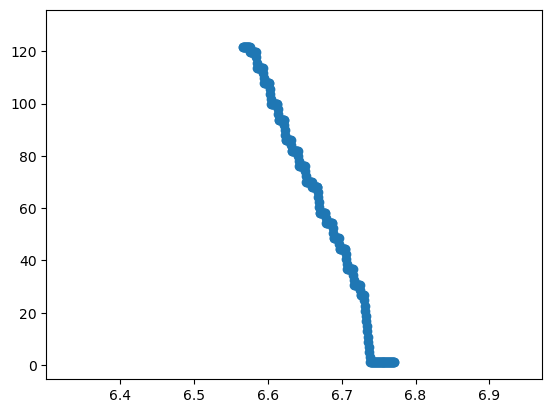

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(time, most_likely_sequence.position)
plt.xlim(event_times[0] + [-0.200, 0.200])

/Users/edeno/Documents/GitHub/non_local_detector/src/non_local_detector/visualization/static.py:166: RuntimeWarning: invalid value encountered in divide
  conditional_non_local_acausal_posterior /= np.nansum(


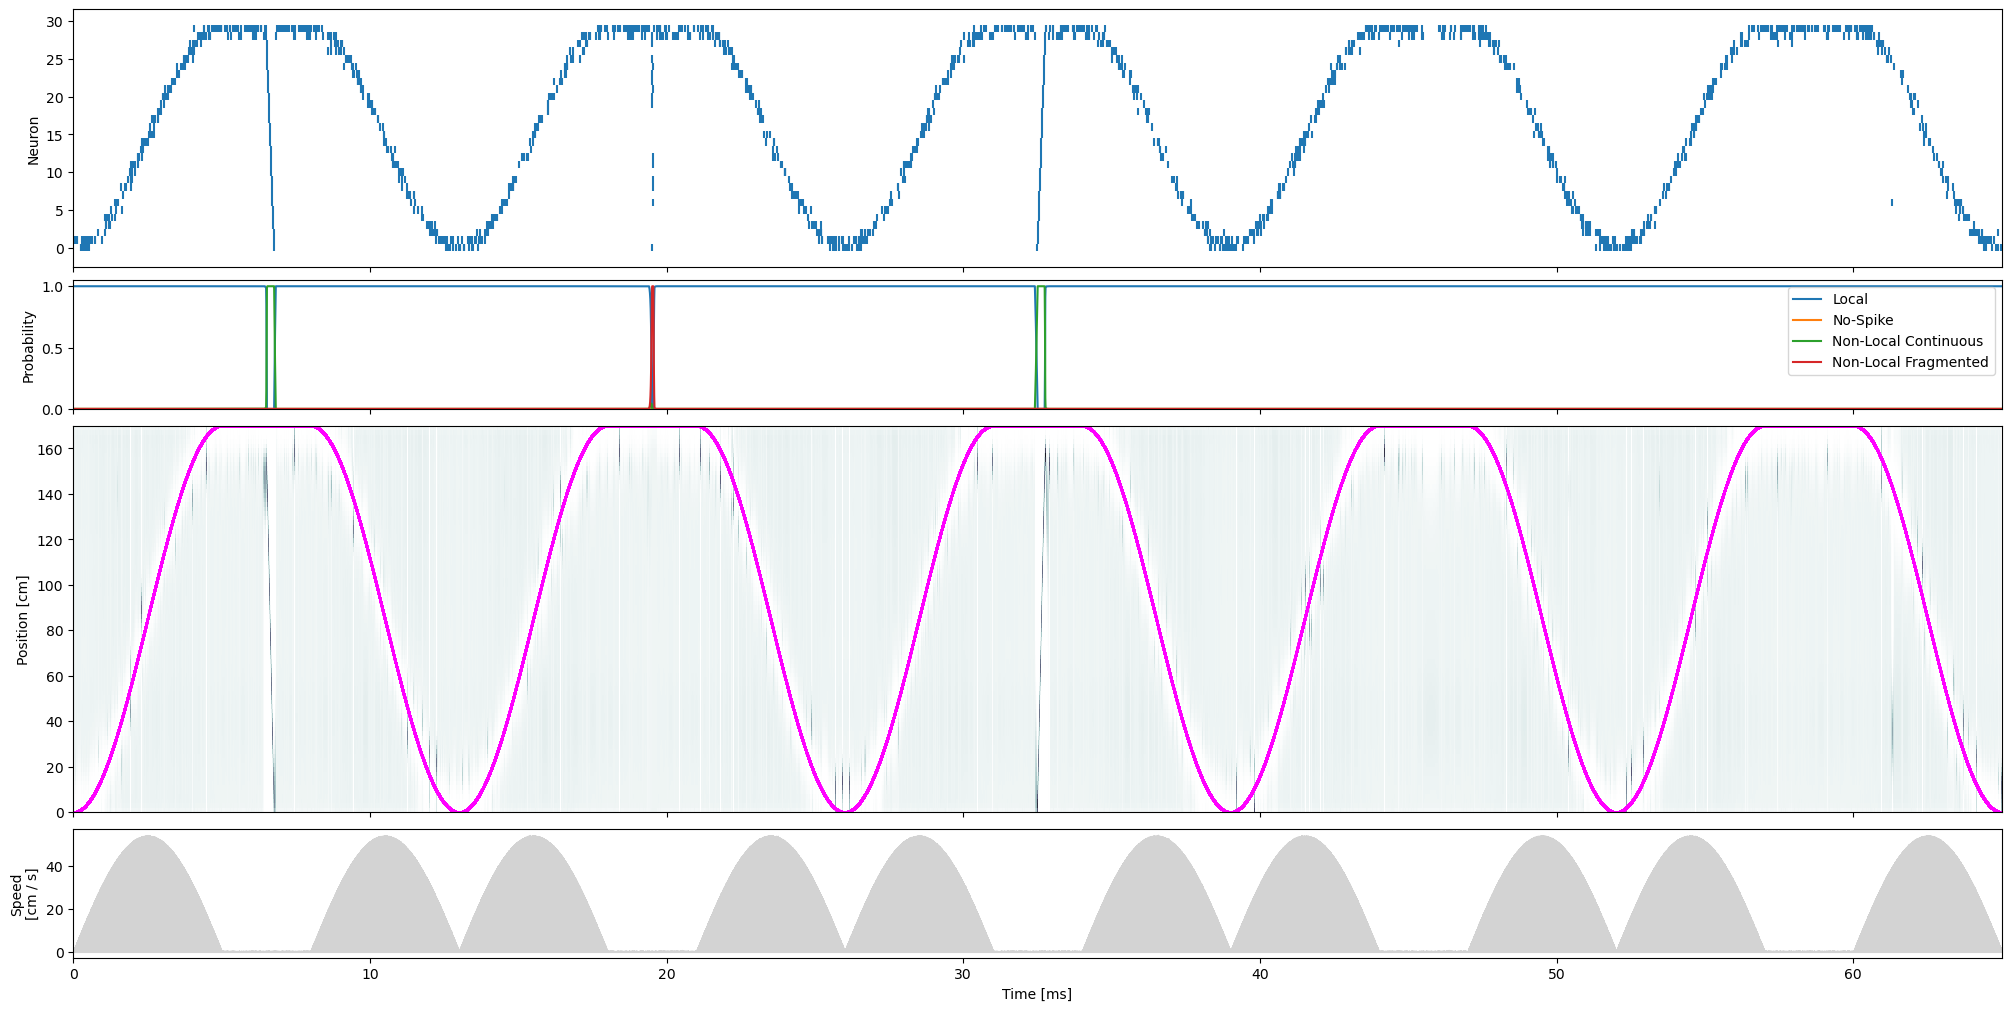

In [4]:
from non_local_detector.visualization import plot_non_local_model

plot_non_local_model(
    time,
    position,
    spike_times,
    speed,
    detector,
    results,
    figsize=(20, 10),
)

In [8]:
detector.environments[0].place_bin_size

2.0

In [14]:
detector.initial_conditions_.shape

(174,)

In [17]:
detector.initial_conditions_.sum()

np.float64(1.0000000000000093)

In [18]:
detector.continuous_state_transitions_.sum(axis=1)

array([4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4.])

In [19]:
detector.environments[0].place_bin_centers_.shape

(86, 1)

In [22]:
detector.encoding_model_[("", 0)].keys()

dict_keys(['environment', 'marginal_models', 'occupancy_model', 'occupancy', 'mean_rates', 'place_fields', 'no_spike_part_log_likelihood', 'is_track_interior', 'disable_progress_bar'])

In [24]:
detector.encoding_model_[("", 0)]["mean_rates"]

[np.float64(0.0009416931644374584),
 np.float64(0.0009625515581866589),
 np.float64(0.0007114145794247685),
 np.float64(0.0006905043581301219),
 np.float64(0.00043941611516155025),
 np.float64(0.0003766577234316482),
 np.float64(0.00035572465735082977),
 np.float64(0.00038711304676557114),
 np.float64(0.00033480245699802345),
 np.float64(0.00031386813974618204),
 np.float64(0.0002929581186638476),
 np.float64(0.0004080434258848905),
 np.float64(0.000230184792093394),
 np.float64(0.0003871143091634528),
 np.float64(0.00032432952870233776),
 np.float64(0.0003034261189923085),
 np.float64(0.00031387950319826006),
 np.float64(0.0004289771531029394),
 np.float64(0.000449891339349826),
 np.float64(0.0003661994967073409),
 np.float64(0.0003661899626095048),
 np.float64(0.0003766574889150457),
 np.float64(0.00034526732752778475),
 np.float64(0.0003871183177757645),
 np.float64(0.0004394229043198124),
 np.float64(0.000512689589189361),
 np.float64(0.0005545499686604376),
 np.float64(0.000671095

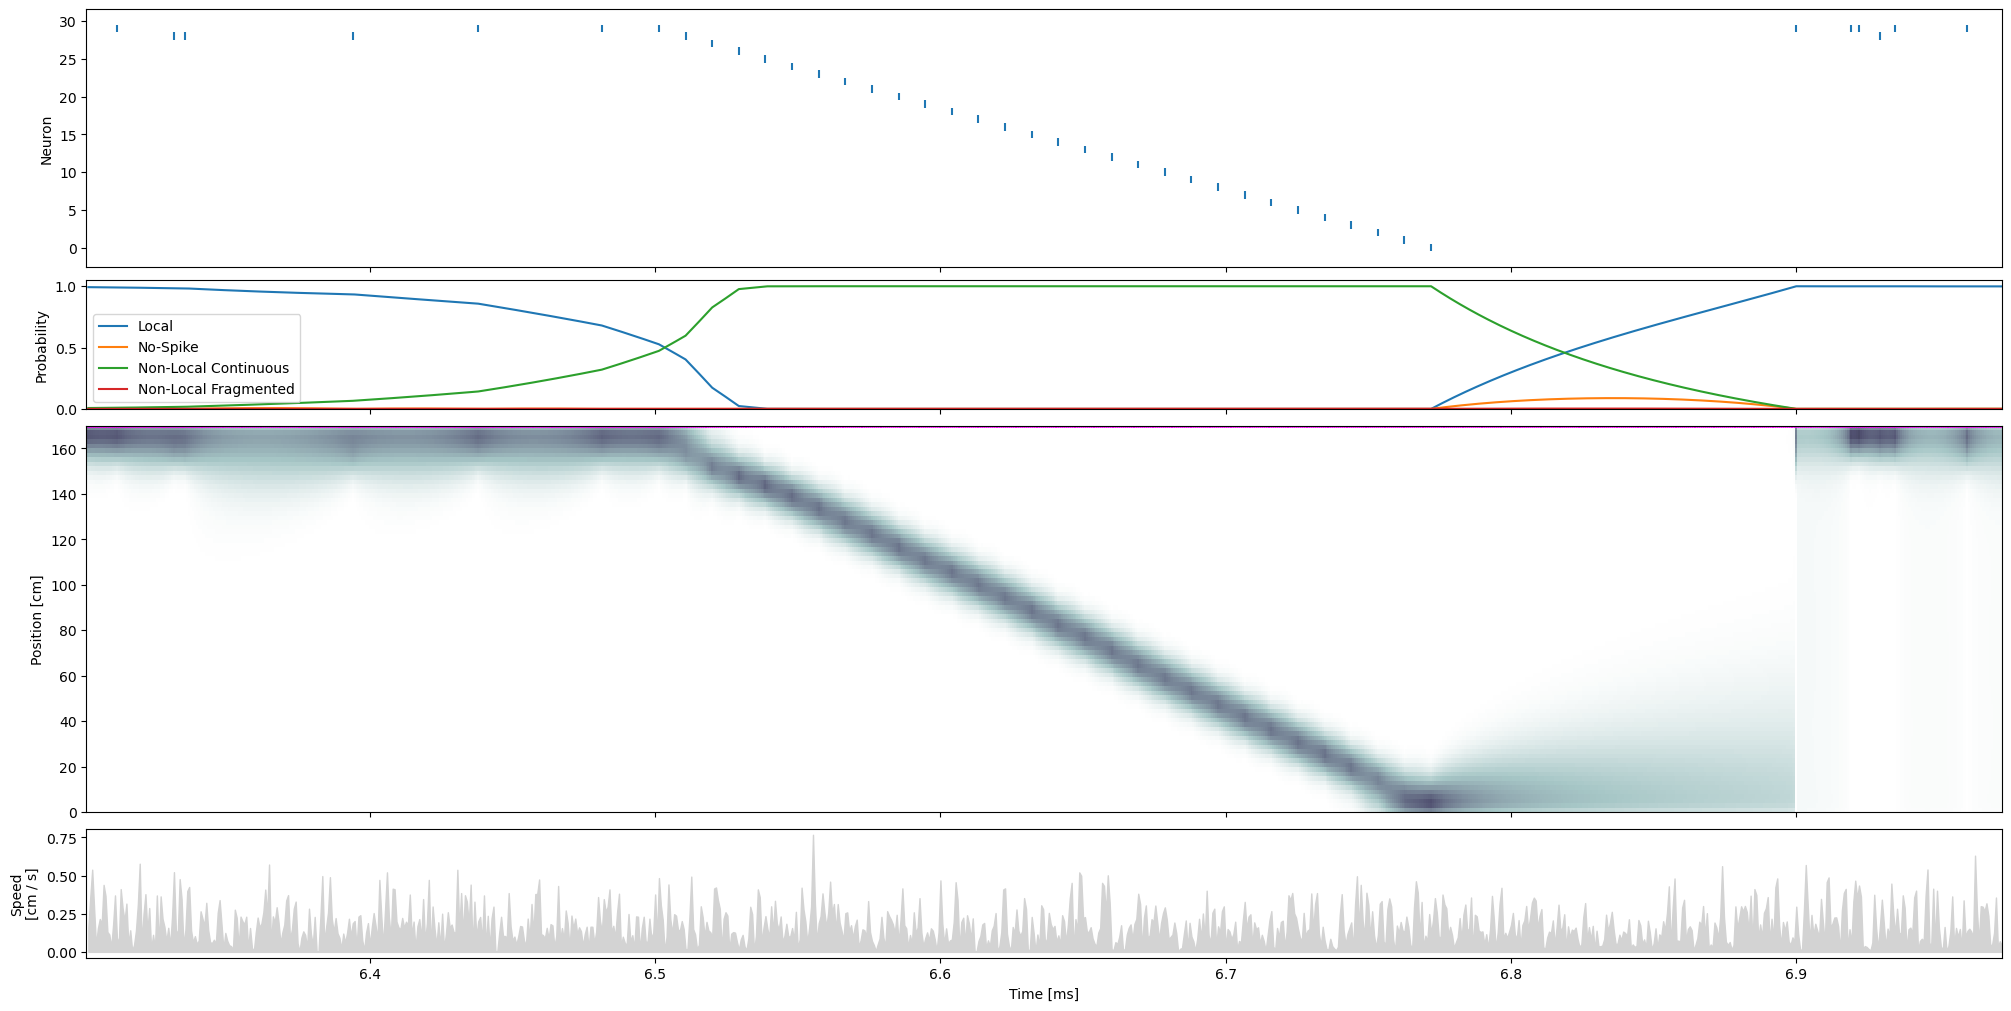

In [11]:
from non_local_detector.visualization import plot_non_local_model

plot_non_local_model(
    time,
    position,
    spike_times,
    speed,
    detector,
    results,
    figsize=(20, 10),
    time_slice=slice(event_times[0][0] - 0.2, event_times[0][1] + 0.2),
)

In [ ]:
import jax
import jax.numpy as jnp


@jax.jit
def hmm_posterior_mode(
    initial_distribution,
    transition_matrix,
    log_likelihoods,
):
    r"""Compute the most likely state sequence. This is called the Viterbi algorithm.

    Args:
        initial_distribution: $p(z_1 \mid u_1, \theta)$
        transition_matrix: $p(z_{t+1} \mid z_t, u_t, \theta)$
        log_likelihoods: $p(y_t \mid z_t, u_t, \theta)$ for $t=1,\ldots, T$.
        transition_fn: function that takes in an integer time index and returns a $K \times K$ transition matrix.

    Returns:
        most likely state sequence

    """
    # Run the backward pass
    def _backward_pass(best_next_score, t):
        scores = jnp.log(transition_matrix) + best_next_score + log_likelihoods[t + 1]
        best_next_state = jnp.argmax(scores, axis=1)
        best_next_score = jnp.max(scores, axis=1)
        return best_next_score, best_next_state

    num_timesteps, num_states = log_likelihoods.shape
    best_second_score, rev_best_next_states = jax.lax.scan(
        _backward_pass, jnp.zeros(num_states), jnp.arange(num_timesteps - 2, -1, -1)
    )
    best_next_states = rev_best_next_states[::-1]

    # Run the forward pass
    def _forward_pass(state, best_next_state):
        next_state = best_next_state[state]
        return next_state, next_state

    first_state = jnp.argmax(
        jnp.log(initial_distribution) + log_likelihoods[0] + best_second_score
    )
    _, states = jax.lax.scan(_forward_pass, first_state, best_next_states)

    return jnp.concatenate([jnp.array([first_state]), states])

In [ ]:
import numpy as np

initial_distribution=detector.initial_conditions_
transition_matrix=(
    detector.discrete_state_transitions_[
        np.ix_(detector.state_ind_, detector.state_ind_)
    ]
    * detector.continuous_state_transitions_
)
log_likelihoods=detector.log_likelihood_

def _backward_pass(best_next_score, t):
    scores = jnp.log(transition_matrix) + best_next_score + log_likelihoods[t + 1]
    best_next_state = jnp.argmax(scores, axis=1)
    best_next_score = jnp.max(scores, axis=1)
    return best_next_score, best_next_state

num_timesteps, num_states = log_likelihoods.shape
best_second_score, rev_best_next_states = jax.lax.scan(
    _backward_pass, jnp.zeros(num_states), jnp.arange(num_timesteps - 2, -1, -1)
)
best_next_states = rev_best_next_states[::-1]

In [ ]:
best_second_score.shape, rev_best_next_states.shape

In [ ]:
best_second_score2, best_next_states2 = jax.lax.scan(
    _backward_pass, jnp.zeros(num_states), jnp.arange(num_timesteps - 1), reverse=True
)

In [ ]:
np.allclose(best_next_states, best_next_states2)

In [ ]:
import numpy as np

most_likely_state_id = hmm_posterior_mode(
    initial_distribution=detector.initial_conditions_,
    transition_matrix=(
        detector.discrete_state_transitions_[
            np.ix_(detector.state_ind_, detector.state_ind_)
        ]
        * detector.continuous_state_transitions_
    ),
    log_likelihoods=detector.log_likelihood_,
)
most_likely_state = results.state_bins[most_likely_state_id]

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].scatter(results.time, most_likely_state.to_dataframe().position.values, s=1)
axes[1].plot(time, most_likely_state_id)
for state_prob, state_name in zip(
    results.acausal_state_probabilities.values.T, results.states.values, strict=False
):
    axes[2].plot(time, state_prob, label=state_name)

axes[2].legend()
plt.xlim((6, 7))

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].scatter(results.time, most_likely_state.to_dataframe().position.values, s=1)
axes[1].scatter(time, most_likely_state_id, s=10)
axes[1].axhline(0, color="black", linestyle="--")
for state_prob, state_name in zip(
    results.acausal_state_probabilities.values.T, results.states.values, strict=False
):
    axes[2].plot(time, state_prob, label=state_name)

axes[2].legend()
plt.xlim((32.4, 32.8))

In [ ]:
detector.plot_discrete_state_transition()

In [ ]:
@jax.jit
def hmm_posterior_mode2(
    initial_distribution,
    transition_matrix,
    log_likelihoods,
):
    r"""Compute the most likely state sequence. This is called the Viterbi algorithm.

    Args:
        initial_distribution: $p(z_1 \mid u_1, \theta)$
        transition_matrix: $p(z_{t+1} \mid z_t, u_t, \theta)$
        log_likelihoods: $p(y_t \mid z_t, u_t, \theta)$ for $t=1,\ldots, T$.
        transition_fn: function that takes in an integer time index and returns a $K \times K$ transition matrix.

    Returns:
        most likely state sequence

    """
    # Run the backward pass
    def _backward_pass(best_next_score, t):
        scores = jnp.log(transition_matrix) + best_next_score + log_likelihoods[t + 1]
        best_next_state = jnp.argmax(scores, axis=1)
        best_next_score = jnp.max(scores, axis=1)
        return best_next_score, best_next_state

    num_timesteps, num_states = log_likelihoods.shape
    best_second_score, best_next_states = jax.lax.scan(
        _backward_pass,
        jnp.zeros(num_states),
        jnp.arange(num_timesteps-1),
        reverse=True,
    )

    # Run the forward pass
    def _forward_pass(state, best_next_state):
        next_state = best_next_state[state]
        return next_state, next_state

    first_state = jnp.argmax(
        jnp.log(initial_distribution) + log_likelihoods[0] + best_second_score
    )
    _, states = jax.lax.scan(_forward_pass, first_state, best_next_states)

    return jnp.concatenate([jnp.array([first_state]), states])

most_likely_state_id2 = hmm_posterior_mode2(
    initial_distribution=detector.initial_conditions_,
    transition_matrix=(
        detector.discrete_state_transitions_[
            np.ix_(detector.state_ind_, detector.state_ind_)
        ]
        * detector.continuous_state_transitions_
    ),
    log_likelihoods=detector.log_likelihood_,
)

np.all(np.asarray(most_likely_state_id) == np.asarray(most_likely_state_id2))

In [ ]:
first_state = jnp.argmax(
    jnp.log(initial_distribution) + log_likelihoods[0] + best_second_score
)
best_next_states[0, first_state]

In [ ]:
most_likely_state

In [ ]:
most_likely_state.shape, most_likely_state2.shape

In [ ]:
from non_local_detector import ContFragSortedSpikesClassifier, RandomWalk, Uniform

continuous_st = [[RandomWalk(movement_var=1.0), Uniform()], [Uniform(), Uniform()]]

decoder = ContFragSortedSpikesClassifier(
    continuous_transition_types=continuous_st,
)
results2 = decoder.estimate_parameters(
    position_time=time,
    position=position,
    spike_times=spike_times,
    is_training=is_training,
    time=time,
    store_log_likelihood=True,
)

In [ ]:
import numpy as np
import scipy.interpolate

from non_local_detector.likelihoods.common import get_spikecount_per_time_bin

true_log_likelihood = np.zeros_like(decoder.log_likelihood_)

for neuron_spike_times, neuron_place_field in zip(spike_times, place_fields.T, strict=False):
    spike_counts = get_spikecount_per_time_bin(neuron_spike_times, time)
    neuron_place_intensity = (
        scipy.interpolate.interp1d(position, neuron_place_field)(
            decoder.environments[0].place_bin_centers_
        )
        / sampling_frequency
    ).squeeze()
    neuron_log_likelihoood = jax.scipy.stats.poisson.logpmf(
        spike_counts[:, None], neuron_place_intensity[None, :]
    )

    true_log_likelihood += np.concatenate(
        [neuron_log_likelihoood, neuron_log_likelihoood], axis=1
    )

true_log_likelihood.shape

In [ ]:
import numpy as np

most_likely_state_id2 = hmm_posterior_mode(
    initial_distribution=decoder.initial_conditions_,
    transition_matrix=(
        decoder.discrete_state_transitions_[
            np.ix_(decoder.state_ind_, decoder.state_ind_)
        ]
        * decoder.continuous_state_transitions_
    ),
    # log_likelihoods=decoder.log_likelihood_,
    log_likelihoods=true_log_likelihood,
)

most_likely_state2 = results2.state_bins[most_likely_state_id2]

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].plot(time, position, color="magenta")
axes[0].scatter(results2.time, most_likely_state2.to_dataframe().position.values, s=1)
axes[1].plot(time, most_likely_state_id2)
for state_prob, state_name in zip(
    results2.acausal_state_probabilities.values.T, results2.states.values, strict=False
):
    axes[2].plot(time, state_prob, label=state_name)

axes[2].legend()
plt.xlim((6, 7))

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].plot(time, position, color="magenta")
axes[0].scatter(results2.time, most_likely_state2.to_dataframe().position.values, s=1)
axes[1].plot(time, most_likely_state_id2)
for state_prob, state_name in zip(
    results2.acausal_state_probabilities.values.T, results2.states.values, strict=False
):
    axes[2].plot(time, state_prob, label=state_name)

axes[2].legend()
plt.xlim((32.4, 32.8))

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].plot(time, position, color="magenta")
axes[0].scatter(results2.time, most_likely_state2.to_dataframe().position.values, s=1)
axes[1].plot(time, most_likely_state_id2)
for state_prob, state_name in zip(
    results2.acausal_state_probabilities.values.T, results2.states.values, strict=False
):
    axes[2].plot(time, state_prob, label=state_name)

axes[2].legend()
plt.xlim((19, 20))

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].plot(time, position, color="magenta")
axes[0].scatter(results2.time, most_likely_state2.to_dataframe().position.values, s=1)
axes[1].plot(time, most_likely_state_id2)
for state_prob, state_name in zip(
    results2.acausal_state_probabilities.values.T, results2.states.values, strict=False
):
    axes[2].plot(time, state_prob, label=state_name)

axes[2].legend()

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
axes[0].plot(time, position, color="magenta")
axes[0].scatter(results2.time, most_likely_state2.to_dataframe().position.values, s=1)
axes[1].plot(time, most_likely_state_id2)
for state_prob, state_name in zip(
    results2.acausal_state_probabilities.values.T, results2.states.values, strict=False
):
    axes[2].plot(time, state_prob, label=state_name)

axes[2].legend()

plt.xlim((0, 5))

In [ ]:
import pandas as pd

self = decoder

position = []
n_position_dims = self.environments[0].place_bin_centers_.shape[1]
environment_names = []
encoding_group_names = []
for obs in self.observation_models:
    if obs.is_local or obs.is_no_spike:
        position.append(np.full((1, n_position_dims), np.nan))
        environment_names.append([None])
        encoding_group_names.append([None])
    else:
        environment = self.environments[
            self.environments.index(obs.environment_name)
        ]
        position.append(environment.place_bin_centers_)
        environment_names.append([obs.environment_name] * environment.place_bin_centers_.shape[0])
        encoding_group_names.append([obs.encoding_group] * environment.place_bin_centers_.shape[0])

position = np.concatenate(position, axis=0)
environment_names = np.concatenate(environment_names, axis=0)
encoding_group_names = np.concatenate(encoding_group_names, axis=0)

states = np.asarray(self.state_names)
if n_position_dims == 1:
    position_names = ["position"]
else:
    position_names = [
        f"{name}_position" for name, _ in zip(["x", "y", "z", "w"], position.T, strict=False)
    ]
state_bins = pd.DataFrame(
    {
        "state": states[self.state_ind_],
        **dict(zip(position_names, position.T, strict=False)),
        "environment": environment_names,
        "encoding_group_names": encoding_group_names,
    }
)

state_bins.iloc[most_likely_state_id2].set_index(pd.Index(time, name="time"))

In [ ]:
obs

In [ ]:
environment_names = [obs.environment_name for obs in self.observation_models]
encoding_group_names = [obs.encoding_group for obs in self.observation_models]

environment_names

In [ ]:
# make this a dataframe instead of an index
pd.DataFrame(
    {
        "state": states[self.state_ind_],
        **dict(zip(position_names, position.T, strict=False)),
    }
)

In [ ]:
states[self.state_ind_].shape, position.T.shape